In [1]:
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [2]:
samples = np.random.standard_normal(size = (10,100))

samples

array([[ 0.74497751,  0.09991561, -0.57401155, -0.54484402,  0.57110763,
        -0.59291233, -1.09385081,  0.92500209,  1.0694652 , -0.96083449,
         1.16619501, -0.03985852, -0.05887276,  0.6318765 ,  0.89920186,
         1.88568437, -2.19694578,  3.28222701,  0.90492311,  0.27317495,
        -1.75176239,  0.70010097, -1.24165348,  1.2788474 , -1.30564484,
         0.571699  , -0.53858326, -0.95827633, -0.11799553, -0.79643858,
        -0.39634333, -1.07169834, -1.76650649, -1.19757337, -1.28503008,
         1.17657556,  0.42381197, -0.78481055, -0.28624986,  0.46159969,
        -0.36972591, -0.50174505, -0.4181111 , -0.13408191,  0.72444147,
         0.21879666, -0.33501613,  0.25831927,  0.52542637, -0.16107463,
         0.38792695,  0.65586085, -1.12591583, -1.94851271,  0.23717806,
        -0.40977343, -0.67836701, -0.247612  ,  0.34784924,  1.19390752,
        -0.53491073, -0.53960984,  0.79895072,  0.93847851, -0.96874366,
        -0.17324703, -0.49041207, -0.50549049,  1.3

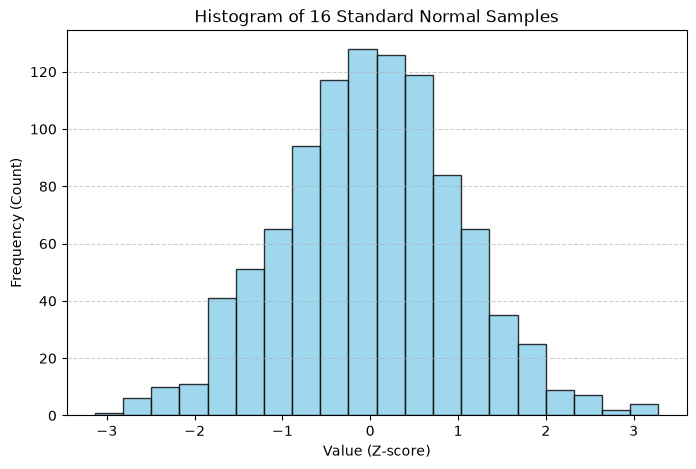

In [4]:
flat_samples = samples.flatten()

# 3. Plot the histogram
plt.figure(figsize=(8, 5))
plt.hist(flat_samples, bins=20, color='skyblue', edgecolor='black', alpha=0.8)

# 4. Format and show
plt.title('Histogram of 16 Standard Normal Samples')
plt.xlabel('Value (Z-score)')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Python's builtin random module, by contrast samples only one value at a time

In [7]:
from random import normalvariate

normalvariate(0,1)


-1.0864444219425686

In [ ]:
N = 1_000_000

%timeit samples = [ normalvariate(0,1) for _ in range(N)]

%timeit samples = np.random.standard_normal(N)

rng = np.random.default_rng() #Newwer API for random number generation in numpy. More flexible and faster

%timeit samples_1d = rng.standard_normal(N)

204 ms ± 402 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
11.1 ms ± 25.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.44 ms ± 18.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


1. True Random Numbers
True random numbers are unpredictable and non-deterministic. They are generated by measuring unpredictable physical phenomena in the real world, rather than relying on a mathematical algorithm.

How it works: A computer might measure the exact microsecond of a user's keystrokes, the electrical noise in a circuit, atmospheric radio noise, or even radioactive decay. These physical processes are inherently chaotic and cannot be predicted or replicated.

The Catch: Generating true random numbers is slow and computationally expensive because the system has to wait for physical events to occur to gather "entropy" (randomness).

Use Cases: Highly sensitive cryptography, generating root encryption keys, lotteries, and secure gambling algorithms.

2. Pseudorandom Numbers (PRNGs)
Pseudorandom numbers are deterministic. They appear random, pass statistical tests for randomness, and follow expected distributions (like the standard normal distribution you plotted earlier), but they are actually the result of a predictable mathematical formula.

How it works: A Pseudorandom Number Generator (PRNG) starts with a single starting value called a seed. From that seed, a complex algorithm (like the PCG64 algorithm used by NumPy's default_rng()) calculates the next number, and the next, in a long sequence.

The Catch: Because it is just a formula, if someone knows the seed and the algorithm, they can perfectly recreate the entire sequence of numbers.

Use Cases: Data science, machine learning, video games, simulations, and general programming.



If you do not explicitly provide a seed to a Pseudorandom Number Generator (PRNG) like NumPy's default_rng(), the software will automatically generate a seed for you behind the scenes.

It does this by querying the operating system for a true random or highly unpredictable number to use as the starting point.

Here is exactly what happens when you run rng = np.random.default_rng() without a seed:

1. The OS Entropy Pool
Your operating system (macOS, Windows, or Linux) constantly maintains a pool of "entropy"—random data gathered from unpredictable hardware events. It collects microsecond-level timing variations from:

Mouse movements

Keystrokes

Disk drive activity

Network packet arrival times

Hardware temperature fluctuations

2. Seeding the Algorithm
When NumPy needs a seed, it asks the OS for a chunk of this entropy (usually by calling a system function like /dev/urandom on Mac/Linux or CryptGenRandom on Windows).

The OS hands back a highly unpredictable, essentially true random number. NumPy then takes that OS-provided number and uses it as the seed for its PRNG math formula.

The Result
Because the OS-provided seed is derived from chaotic physical events (like the exact millisecond you moved your mouse last week), it will be completely different every single time you run the script.



#### Functions like numpy.random.standard_normal use the numpy.random module's default random number generator, but your code can be used an explicit generator

In [10]:
rng = np.random.default_rng(seed = 12345)

data = rng.standard_normal(size = (10,100))

data

array([[-1.42382504e+00,  1.26372846e+00, -8.70661738e-01,
        -2.59173235e-01, -7.53433070e-02, -7.40884652e-01,
        -1.36779270e+00,  6.48892802e-01,  3.61058113e-01,
        -1.95286306e+00,  2.34740965e+00,  9.68496906e-01,
        -7.59387180e-01,  9.02198274e-01, -4.66953173e-01,
        -6.06895187e-02,  7.88844345e-01, -1.25666813e+00,
         5.75857514e-01,  1.39897899e+00,  1.32229806e+00,
        -2.99698515e-01,  9.02919341e-01, -1.62158273e+00,
        -1.58189261e-01,  4.49483932e-01, -1.34360107e+00,
        -8.16875907e-02,  1.72473993e+00,  2.61815943e+00,
         7.77361344e-01,  8.28633196e-01, -9.58988313e-01,
        -1.20938829e+00, -1.41229201e+00,  5.41546830e-01,
         7.51939396e-01, -6.58760320e-01, -1.22867499e+00,
         2.57557768e-01,  3.12902918e-01, -1.30811690e-01,
         1.26998312e+00, -9.29624577e-02, -6.61508890e-02,
        -1.10821447e+00,  1.35956851e-01,  1.34707776e+00,
         6.11440210e-02,  7.09146003e-02,  4.33654537e-0

In [13]:
print([_ for _ in dir(np.random) if not _.startswith('_')])

['BitGenerator', 'Generator', 'MT19937', 'PCG64', 'PCG64DXSM', 'Philox', 'RandomState', 'SFC64', 'SeedSequence', 'beta', 'binomial', 'bit_generator', 'bytes', 'chisquare', 'choice', 'default_rng', 'dirichlet', 'exponential', 'f', 'gamma', 'geometric', 'get_bit_generator', 'get_state', 'gumbel', 'hypergeometric', 'laplace', 'logistic', 'lognormal', 'logseries', 'mtrand', 'multinomial', 'multivariate_normal', 'negative_binomial', 'noncentral_chisquare', 'noncentral_f', 'normal', 'pareto', 'permutation', 'poisson', 'power', 'rand', 'randint', 'randn', 'random', 'random_integers', 'random_sample', 'ranf', 'rayleigh', 'sample', 'seed', 'set_bit_generator', 'set_state', 'shuffle', 'standard_cauchy', 'standard_exponential', 'standard_gamma', 'standard_normal', 'standard_t', 'test', 'triangular', 'uniform', 'vonmises', 'wald', 'weibull', 'zipf']


In [16]:
help(np.maximum)

Help on ufunc in module numpy:

maximum = <ufunc 'maximum'>
    maximum(x1, x2, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])
    
    Element-wise maximum of array elements.
    
    Compare two arrays and return a new array containing the element-wise
    maxima. If one of the elements being compared is a NaN, then that
    element is returned. If both elements are NaNs then the first is
    returned. The latter distinction is important for complex NaNs, which
    are defined as at least one of the real or imaginary parts being a NaN.
    The net effect is that NaNs are propagated.
    
    Parameters
    ----------
    x1, x2 : array_like
        The arrays holding the elements to be compared.
        If ``x1.shape != x2.shape``, they must be broadcastable to a common
        shape (which becomes the shape of the output).
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stor

In [21]:
x = rng.standard_normal(8)

y = rng.standard_normal(8)

print("x: ", x)
print("y: ", y)
np.maximum(x,y)

x:  [ 0.80966564 -0.80903401  1.01707139 -0.20900614 -0.19196842 -0.37999948
 -0.07390087  0.54840326]
y:  [ 0.89823799  0.90096505  3.46197581 -0.28949683  1.22068709 -0.60747446
 -0.13559357 -1.10708975]


array([ 0.89823799,  0.90096505,  3.46197581, -0.20900614,  1.22068709,
       -0.37999948, -0.07390087,  0.54840326])

In [22]:
help(np.max)

Help on _ArrayFunctionDispatcher in module numpy:

max(a, axis=None, out=None, keepdims=<no value>, initial=<no value>, where=<no value>)
    Return the maximum of an array or maximum along an axis.
    
    Parameters
    ----------
    a : array_like
        Input data.
    axis : None or int or tuple of ints, optional
        Axis or axes along which to operate.  By default, flattened input is
        used. If this is a tuple of ints, the maximum is selected over
        multiple axes, instead of a single axis or all the axes as before.
    
    out : ndarray, optional
        Alternative output array in which to place the result.  Must
        be of the same shape and buffer length as the expected output.
        See :ref:`ufuncs-output-type` for more details.
    
    keepdims : bool, optional
        If this is set to True, the axes which are reduced are left
        in the result as dimensions with size one. With this option,
        the result will broadcast correctly against t

In [23]:
arr = rng.standard_normal(7) * 5

arr

array([ 6.39182424,  1.62650514,  0.98366356, -0.25384538,  4.97719949,
       -2.1544659 ,  2.36311566])

In [26]:

remainder, whole_part = np.modf(arr)

remainder,whole_part


(array([ 0.39182424,  0.62650514,  0.98366356, -0.25384538,  0.97719949,
        -0.1544659 ,  0.36311566]),
 array([ 6.,  1.,  0., -0.,  4., -2.,  2.]))

In [28]:
out = np.zeros_like(arr)

#### Ufunc accept an optional argument that allows them to assign their results into an existing array rather than create a new one

In [29]:
np.add(arr,1,out = out)

array([ 7.39182424,  2.62650514,  1.98366356,  0.74615462,  5.97719949,
       -1.1544659 ,  3.36311566])

In [30]:
out

array([ 7.39182424,  2.62650514,  1.98366356,  0.74615462,  5.97719949,
       -1.1544659 ,  3.36311566])

In [36]:
points = np.arange(10)

points

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [41]:
points[:5], points[5:]

(array([0, 1, 2, 3, 4]), array([5, 6, 7, 8, 9]))

In [54]:
xs, xy = np.meshgrid(points[:5], points[5:])

print(xs)
print(xy)



[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]
[[5 5 5 5 5]
 [6 6 6 6 6]
 [7 7 7 7 7]
 [8 8 8 8 8]
 [9 9 9 9 9]]


In [57]:
z = np.sqrt(xs**2 + xy**2)

z


array([[5.        , 5.09901951, 5.38516481, 5.83095189, 6.40312424],
       [6.        , 6.08276253, 6.32455532, 6.70820393, 7.21110255],
       [7.        , 7.07106781, 7.28010989, 7.61577311, 8.06225775],
       [8.        , 8.06225775, 8.24621125, 8.54400375, 8.94427191],
       [9.        , 9.05538514, 9.21954446, 9.48683298, 9.8488578 ]])

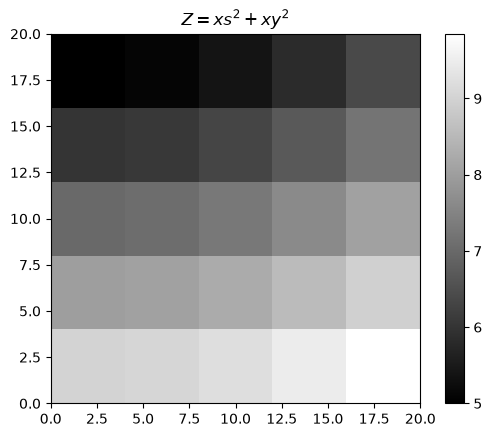

In [61]:
plt.imshow(z, cmap="gray", extent=[0, 20,0, 20])
plt.colorbar()
plt.title(r"$Z = xs^{2} + xy^{2}$")
plt.show()


##### Scenario :: Suppose we wanted to take a value from
##### whenever the corresponding value in
##### xarr
##### is True, and otherwise take the value from yarr. A list comprehension doing
##### cond
##### this might look like:

In [ ]:
import time
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])
start_time = time.process_time()
result = [(x if c else y) for x, y, c in zip(xarr, yarr, cond)]
end_time = time.process_time()
print(result)
print(f"Start time: {start_time}, End time: {end_time}")

#This has multiple problems. First, it will not be very fast for large arrays (because all
#the work is being done in interpreted Python code). Second, it will not work with
#multidimensional arrays





[np.float64(1.1), np.float64(2.2), np.float64(1.3), np.float64(1.4), np.float64(2.5)]
Start time: 37.811716, End time: 37.811761


In [67]:
start_time = time.process_time()
result = np.where(cond, xarr, yarr)
end_time = time.process_time()
print(result)
print(f"Start time: {start_time}, End time: {end_time}")



[1.1 2.2 1.3 1.4 2.5]
Start time: 37.822097, End time: 37.822604


The second and third arguments to
don’t need to be arrays; one or
numpy.where
both of them can be scalars. A typical use of
in data analysis is to produce a
where
new array of values based on

Scenario : 2 Suppose you had a matrix of randomly
generated data and you wanted to replace all positive values with 2 and all negative
values with –2. This is possible to do with numpy.where:

In [69]:
arr = rng.standard_normal((4, 4))

print(arr)

arr > 0

[[-0.28289792  0.05640479 -1.16277153  1.78556675]
 [ 0.54059787  1.38087593  1.25949693 -0.14288909]
 [ 2.53059943  0.20682562 -1.81149988 -2.263577  ]
 [ 0.08621683  0.9589614   0.15468181  1.82611018]]


array([[False,  True, False,  True],
       [ True,  True,  True, False],
       [ True,  True, False, False],
       [ True,  True,  True,  True]])

In [70]:
np.where(arr > 0, 2, -2)

array([[-2,  2, -2,  2],
       [ 2,  2,  2, -2],
       [ 2,  2, -2, -2],
       [ 2,  2,  2,  2]])

Scenario : 2.1 - replace all positive values in arr with the constant 2, like so:

In [71]:
np.where(arr > 0, 2, arr) # set only positive values to 2

array([[-0.28289792,  2.        , -1.16277153,  2.        ],
       [ 2.        ,  2.        ,  2.        , -0.14288909],
       [ 2.        ,  2.        , -1.81149988, -2.263577  ],
       [ 2.        ,  2.        ,  2.        ,  2.        ]])

In [77]:
arr = np.arange(16).reshape(4,4)

overall_sum = np.sum(arr) 

print(arr)
overall_sum, arr.sum()




[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


(np.int64(120), np.int64(120))

In [75]:
#Sum accross the rows
print(f"arr.sum(axis = 0): {arr.sum(axis = 0)}")

#Sum accross the columns
print(f"arr.sum(axis = 1): {arr.sum(axis = 1)}")



arr.sum(axis = 0): [4. 4. 4. 4.]
arr.sum(axis = 1): [4. 4. 4. 4.]


In [78]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])

##Cumulative sum
print(f"arr.cumsum(): {arr.cumsum()}")






arr.cumsum(): [ 0  1  3  6 10 15 21 28]


In [80]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])

arr

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [82]:
#cumulative sum accross the rows
print(f"arr.cumsum(axis = 0) Rows: {arr.cumsum(axis = 0)}")

#cumulative sum accross the columns
print(f"arr.cumsum(axis = 1) Columns: {arr.cumsum(axis = 1)}")



arr.cumsum(axis = 0) Rows: [[ 0  1  2]
 [ 3  5  7]
 [ 9 12 15]]
arr.cumsum(axis = 1) Columns: [[ 0  1  3]
 [ 3  7 12]
 [ 6 13 21]]


In [85]:
arr > 2

array([[False, False, False],
       [ True,  True,  True],
       [ True,  True,  True]])

In [86]:
arr = rng.standard_normal(6)

arr

array([-0.21695713,  0.65111301,  0.8222478 , -0.95022429,  0.3923083 ,
        0.45025203])

In [88]:
arr.sort()

arr

array([-0.95022429, -0.21695713,  0.3923083 ,  0.45025203,  0.65111301,
        0.8222478 ])

You can sort each one-dimensional section of values in a multidimensional array in
place along an axis by passing the axis number to sort. In this example data:

In [91]:
arr = rng.standard_normal((5, 3))

arr

array([[-0.25910055, -1.04822523, -0.12300427],
       [ 0.76267169,  0.69269792,  0.82126027],
       [-0.04029032,  1.46333233, -0.3866197 ],
       [ 0.83779548,  0.48785983, -0.67627154],
       [-0.63496907,  0.81724062,  0.10800997]])

sorts the values within each column, while
arr.sort(axis=0)
arr.sort(axis=1)
sorts across each row:

In [92]:
arr.sort(axis=0)

arr

array([[-0.63496907, -1.04822523, -0.67627154],
       [-0.25910055,  0.48785983, -0.3866197 ],
       [-0.04029032,  0.69269792, -0.12300427],
       [ 0.76267169,  0.81724062,  0.10800997],
       [ 0.83779548,  1.46333233,  0.82126027]])

In [93]:
arr.sort(axis=1)

arr

array([[-1.04822523, -0.67627154, -0.63496907],
       [-0.3866197 , -0.25910055,  0.48785983],
       [-0.12300427, -0.04029032,  0.69269792],
       [ 0.10800997,  0.76267169,  0.81724062],
       [ 0.82126027,  0.83779548,  1.46333233]])

In [94]:
arr = np.array([10,20,3,4,5,6,7,8,9,10]).reshape((2,5))
arr

array([[10, 20,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [95]:
np.isin(arr,[3,4,5])

array([[False, False,  True,  True,  True],
       [False, False, False, False, False]])

In [96]:
np.intersect1d(arr,[5,20,6,7])

array([ 5,  6,  7, 20])

In [97]:
np.save("someArr",arr)

In [98]:
np.load("someArr.npy")

array([[10, 20,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [99]:
arr2 = np.array([1,2,3,4,5,6,7,8,9,10])

np.savez("someArr.npz",a = arr, b = arr2) #If your data compresses well, you may wish to use instead:numpy.savez_compressed

In [101]:
arch = np.load("someArr.npz")

arch

NpzFile 'someArr.npz' with keys: a, b

In [102]:
arch["a"]


array([[10, 20,  3,  4,  5],
       [ 6,  7,  8,  9, 10]])

In [103]:
arch["b"]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

#### Random Walk


[0, 1, 0, -1, 0, -1, 0, 1, 0, 1, 2, 3, 4, 3, 2, 1, 0, 1, 2, 3, 4, 3, 4, 5, 6, 5, 6, 7, 8, 7, 8, 9, 8, 9, 10, 11, 10, 11, 10, 11, 12, 11, 12, 13, 12, 13, 12, 13, 12, 13, 14, 13, 14, 15, 14, 13, 14, 13, 12, 11, 12, 13, 14, 13, 14, 15, 14, 13, 12, 11, 12, 11, 12, 13, 12, 11, 10, 11, 10, 9, 10, 11, 10, 9, 10, 11, 12, 13, 12, 11, 12, 11, 12, 13, 12, 11, 12, 13, 14, 15, 14, 15, 14, 13, 14, 13, 14, 13, 12, 11, 10, 11, 12, 11, 12, 13, 14, 15, 14, 13, 12, 13, 12, 11, 12, 13, 12, 11, 12, 13, 14, 13, 14, 15, 14, 15, 16, 17, 16, 17, 16, 15, 14, 15, 14, 13, 12, 13, 12, 13, 14, 15, 14, 15, 14, 13, 12, 11, 12, 11, 12, 11, 10, 11, 12, 11, 12, 13, 12, 11, 10, 11, 12, 11, 12, 13, 12, 13, 12, 13, 14, 13, 12, 13, 12, 11, 12, 11, 12, 13, 14, 15, 16, 17, 16, 17, 18, 19, 20, 19, 20, 21, 22, 21, 20, 21, 22, 23, 24, 25, 24, 23, 24, 23, 24, 25, 26, 27, 28, 29, 30, 31, 30, 31, 30, 29, 28, 29, 28, 27, 26, 25, 26, 25, 24, 25, 26, 27, 28, 29, 28, 29, 28, 27, 28, 27, 28, 27, 28, 29, 28, 29, 28, 29, 28, 29, 28, 27, 2

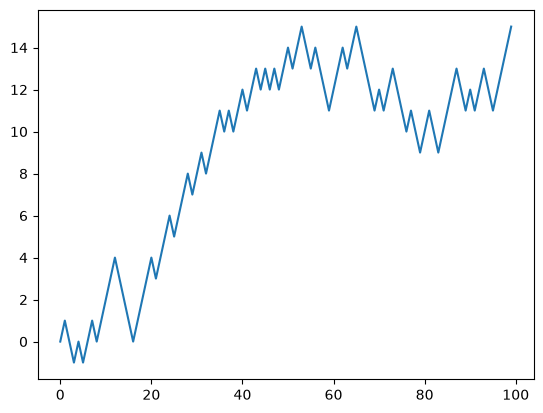

In [105]:
import random
position = 0
walk = [position]
nsteps = 1000
for _ in range(nsteps):
    step = 1 if random.randint(0, 1) else -1
    position += step
    walk.append(position)

print(walk)
plt.plot(walk[:100])
plt.show()




This code snippet demonstrates how to simulate a one-dimensional random walk efficiently using Python's numpy library.
Instead of writing a slow for loop to calculate each step one by one, this code uses vectorization to compute all 1,000 steps at exactly the same time.

Here is the line-by-line breakdown of how it works:

	•	nsteps = 1000 Defines the total number of steps we want our random walk to take.
	•	rng = np.random.default_rng(seed=12345) Initializes NumPy's modern random number generator. Setting a specific seed (like 12345) ensures the results are reproducible—you will get the exact same sequence of "random" numbers every time you run the script.
	•	draws = rng.integers(0, 2, size=nsteps) Simulates 1,000 coin flips. It generates an array of 1,000 integers ranging from 0 (inclusive) to 2 (exclusive). The resulting array, draws, is a massive list filled entirely with 0s and 1s.
	•	steps = np.where(draws == 0, 1, -1) Translates those coin flips into physical steps using np.where, which acts like a vectorized if/else statement. It tells the computer: If the draw is 0, take a step forward (1). Otherwise, take a step backward (-1).
	•	walk = steps.cumsum() This is the core mathematical observation of a random walk. cumsum() calculates the cumulative sum of the array, giving you your exact position on the timeline at every single step.



[1 0 1 0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 1 1 1 0 0 0 0 0 1 0 1 0 0 0
 1 1 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1
 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1
 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 0 0 0 1 1 0 0 1 0 1
 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1
 1 1 1 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 0 0 1 1 1 0 1 1 0 1 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1
 0 1 1 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0 1 0 1 1 0 1 0 0 1 0 1 1 1 0
 1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0
 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 0 0 0 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0
 1 0 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 1 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 1
 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0 1 0
 1 1 0 1 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0
 1 1 1 1 1 0 1 1 1 1 0 0 

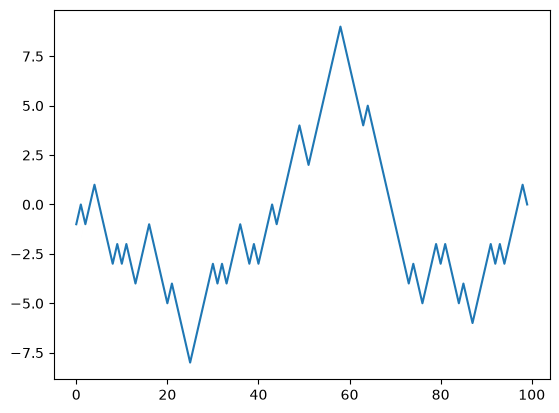

In [106]:
nsteps = 1000

rng = np.random.default_rng(seed=12345) # fresh random generator

draws = rng.integers(0, 2, size=nsteps)

print(draws)

steps = np.where(draws == 0, 1, -1)

walk = steps.cumsum()

print(walk)

plt.plot(walk[:100])
plt.show()


1. Finding the Maximum Distance

In [107]:
# Calculate the absolute maximum distance from the start (0)
max_distance = np.abs(walk).max()

# If you want to see the furthest points in both directions:
print("Lowest point:", walk.min())
print("Highest point:", walk.max())
print("Max distance from origin:", max_distance)

Lowest point: -8
Highest point: 50
Max distance from origin: 50


Finding the First Threshold Crossing

Let's say you want to know how long it took for the random walk to get at least 10 steps away from the origin (either +10 or -10).

You can solve this elegantly using a boolean array and the .argmax() method:

In [108]:
threshold = 10

# Find the first step where the distance reaches or exceeds the threshold
crossing_time = (np.abs(walk) >= threshold).argmax()

print(f"First crossed {threshold} at step: {crossing_time}")

First crossed 10 at step: 155


How this trick works:(np.abs(walk) >= threshold) evaluates every single step in your walk. It returns a massive array of False and True values (e.g., [False, False, False, ..., True, False])..argmax() is a NumPy function designed to return the first index of the maximum value in an array.In a boolean array, True evaluates to 1 and False evaluates to 0. Therefore, .argmax() scans the array and returns the exact index (step number) of the very first True it encounters!Note: If the threshold is never crossed, .argmax() will safely return 0 (because False is the max value, and the first False is at index 0). In production code, you might want to check .any() first to ensure the threshold was actually crossed.

#### Note that using argmax
here is not always efficient because it always makes a full
argmax
scan of the array. In this special case, once a
is observed we know it to be the
True
maximum value.

##### Simulating Many Random Walks at Once

In [111]:
nwalks = 2 # Number of random walks
nsteps = 10 # Number of steps in each walk

draws = rng.integers(0, 2, size=(nwalks, nsteps)) # 2 rows, 10 columns

print(draws)
steps = np.where(draws == 0, 1, -1)
print(steps)
walks = steps.cumsum(axis=1)
print(walks)



[[1 0 1 0 0 1 0 1 1 0]
 [1 1 0 1 0 0 1 0 1 0]]
[[-1  1 -1  1  1 -1  1 -1 -1  1]
 [-1 -1  1 -1  1  1 -1  1 -1  1]]
[[-1  0 -1  0  1  0  1  0 -1  0]
 [-1 -2 -1 -2 -1  0 -1  0 -1  0]]


##### how transpose in numpy helps in calculating inner dot product ?


In linear algebra, calculating the inner (dot) product of two vectors is essentially a specific form of matrix multiplication. The transpose operation (.T in NumPy) is the mechanism used to correctly align the shapes of the data so that the math can actually execute.

Here is exactly why transpose is required and how it works in NumPy.

The Mathematical Rule of the Dot ProductBy definition, the dot product of two column vectors $\mathbf{a}$ and $\mathbf{b}$ is calculated by taking the transpose of the first vector and multiplying it by the second:$$\mathbf{a} \cdot \mathbf{b} = \mathbf{a}^T \mathbf{b}$$

For matrix multiplication to work, the inner dimensions must match. If you have Matrix $A$ with dimensions $(m \times n)$ and Matrix $B$ with dimensions $(j \times k)$, you can only multiply them if $n = j$.


When you define two vectors as standard 2D mathematical column vectors, they both have a shape of $(n, 1)

$Vector A: Shape $(3, 1)

$Vector B: Shape $(3, 1)$



If you try to multiply these directly, the inner dimensions ($1$ and $3$) do not match.By applying a transpose to Vector A, you flip it from a column vector into a row vector. Its shape becomes $(1, 3)$. Now, the multiplication works perfectly: $(1, 3) \times (3, 1) = (1, 1)$, resulting in a single scalar number (the dot product).


How this works in NumPy
In NumPy, how you handle this depends entirely on whether you defined your vectors as 1D arrays or 2D arrays.



Scenario 1: 1D Arrays (The Exception)
If you create standard flat arrays, NumPy takes a shortcut. A 1D array has a shape like (3,)—it is neither a strict row vector nor a column vector.

When you use np.dot() on two 1D arrays, NumPy is smart enough to realize you want an inner product. It automatically calculates the dot product without requiring an explicit transpose.


In [2]:
import numpy as np

a = np.array([1, 2, 3])  # Shape: (3,)
b = np.array([4, 5, 6])  # Shape: (3,)

# NumPy handles the alignment automatically for 1D arrays
result = np.dot(a, b)    # Result: 32

result

np.int64(32)

Scenario 2: 2D Arrays (Where Transpose is Mandatory)
In machine learning, physics, and data science, vectors are usually represented strictly as 2D column vectors or matrices.

If you have two column vectors and try to use standard matrix multiplication (@ or np.matmul), NumPy will enforce the rules of linear algebra. Without a transpose, it will crash.

In [3]:
# Two column vectors
A = np.array([[1], [2], [3]])  # Shape: (3, 1)
B = np.array([[4], [5], [6]])  # Shape: (3, 1)

# This will THROW AN ERROR because inner dimensions (1 and 3) don't match
# result = A @ B  

# Correct approach: Transpose A to shape (1, 3)
result = A.T @ B               

print(A.T.shape)  # (1, 3)
print(result)     # [[32]]

(1, 3)
[[32]]


By adding .T, you physically reoriented the data block in NumPy's memory tracking so that the rows of $A^T$ could correctly multiply against the columns of $B$.